#**1. Compreensão do Negócio**

Na Sprint 1, o grupo definiu como problema principal do projeto FlexMedia – Totem Inteligente:

“Como identificar visitantes com maior chance de interagir com o Totem FlexMedia?”

Com base nesse desafio, foram levantadas três possíveis aplicações de Machine Learning:


*   Classificação: prever se um visitante irá interagir com o totem, a partir de dados históricos e contextuais (perfil, horário, tipo de conteúdo).

*   Regressão: estimar o tempo médio de uso do totem por visitante, apoiando decisões de exibição e desempenho do sistema.

*   Segmentação: agrupar visitantes por comportamento (frequente, ocasional, curioso) para personalizar a experiência.


---



Contexto nesta Sprint 2

O foco atual é aplicar o pipeline CRISP-DM para compreender, preparar e modelar uma base real de visitação — dados do zoológico de Helsinque — a fim de prever o número de visitantes e classificar períodos de alta, média ou baixa demanda.

**Hipóteses de trabalho**


*   Dias de fim de semana e feriados concentram maior número de visitantes.
*   Estações do ano e clima influenciam diretamente a visitação
*   É possível antecipar o volume de público e ajustar o funcionamento do Totem FlexMedia.


**Conexão com o projeto FlexMedia**

As previsões geradas pelos modelos permitem:
*   Ajustar automaticamente o modo de operação do totem (normal, interativo ou pico).
*   Planejar campanhas e conteúdos de acordo com a demanda esperada.
*   Otimizar recursos e melhorar a experiência personalizada dos visitantes.


#**Sprint 2 — CRISP-DM: Notebook**

**Setup e Bibliotecas**

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)

In [103]:
df = pd.read_excel('/content/zoo_visitors_2023_consolidada.xlsx')
df.head(31)

,date,weekday,visitors,month,year,is_weekend,season,is_holiday
0,2023-01-01,dom,1985,1,2023,1,Winter,1
1,2023-01-02,seg,1315,1,2023,0,Winter,0
2,2023-01-03,ter,844,1,2023,0,Winter,0
3,2023-01-04,qua,1165,1,2023,0,Winter,0
4,2023-01-05,qui,689,1,2023,0,Winter,0
5,2023-01-06,sex,1343,1,2023,0,Winter,1
6,2023-01-07,sáb,1843,1,2023,1,Winter,0
7,2023-01-08,dom,1351,1,2023,1,Winter,0
8,2023-01-09,seg,21,1,2023,0,Winter,0
9,2023-01-10,ter,49,1,2023,0,Winter,0


In [104]:
df_winter = df[df['season'] == 'Summer']
display(df_winter)

,date,weekday,visitors,month,year,is_weekend,season,is_holiday
151,2023-06-01,qui,1933,6,2023,0,Summer,0
152,2023-06-02,sex,1146,6,2023,0,Summer,0
153,2023-06-03,sáb,3016,6,2023,1,Summer,0
154,2023-06-04,dom,2611,6,2023,1,Summer,0
155,2023-06-05,seg,1750,6,2023,0,Summer,0
...,...,...,...,...,...,...,...,...
238,2023-08-27,dom,744,8,2023,1,Summer,0
239,2023-08-28,seg,147,8,2023,0,Summer,0
240,2023-08-29,ter,1027,8,2023,0,Summer,0
241,2023-08-30,qua,144,8,2023,0,Summer,0


#**Cópia do df, para manter a integridade do original**

In [105]:
df1 = df.copy()

#**Análise Descritiva**

In [106]:
nulos = df1.isnull().sum()
nulos

,0
date,0
weekday,0
visitors,0
month,0
year,0
is_weekend,0
season,0
is_holiday,0


In [107]:
df1.duplicated().sum()

np.int64(0)

In [108]:
df1.describe()

,date,visitors,month,year,is_weekend,is_holiday
count,365,365.000000,365.000000,365.0,365.000000,365.000000
mean,2023-07-02 00:00:00,1343.726027,6.526027,2023.0,0.287671,0.038356
min,2023-01-01 00:00:00,21.000000,1.000000,2023.0,0.000000,0.000000
25%,2023-04-02 00:00:00,251.000000,4.000000,2023.0,0.000000,0.000000
50%,2023-07-02 00:00:00,676.000000,7.000000,2023.0,0.000000,0.000000
75%,2023-10-01 00:00:00,1841.000000,10.000000,2023.0,1.000000,0.000000
max,2023-12-31 00:00:00,13039.000000,12.000000,2023.0,1.000000,1.000000
std,NaN,1646.886313,3.452584,0.0,0.453298,0.192318


In [109]:
# Identificar variáveis categóricas e numéricas
categorical_cols = df1.select_dtypes(include=['object']).columns
print("\nVariáveis categóricas:", categorical_cols)

numerical_cols = df1.select_dtypes(exclude=['object']).columns
print("\nVariáveis numéricas:", numerical_cols)


Variáveis categóricas: Index(['weekday', 'season'], dtype='object')

Variáveis numéricas: Index(['date', 'visitors', 'month', 'year', 'is_weekend', 'is_holiday'], dtype='object')


In [110]:
label_weekday = LabelEncoder()
label_season = LabelEncoder()
df1['weekday'] = label_weekday.fit_transform(df1['weekday'])
df1['season'] = label_season.fit_transform(df1['season'])

In [111]:
for col in ['is_weekend', 'is_holiday']:
    print(f'\n{col}:')
    print(df1[col].value_counts())


is_weekend:
is_weekend
0    260
1    105
Name: count, dtype: int64

is_holiday:
is_holiday
0    351
1     14
Name: count, dtype: int64


In [112]:
df1['date'].dt.month.value_counts().sort_index()


,count
date,
1,31
2,28
3,31
4,30
5,31
6,30
7,31
8,31
9,30


#**Regressão – Previsão de visitantes**

In [132]:
X = df1[['month', 'weekday', 'is_weekend', 'is_holiday', 'season']]
y = df1['visitors']

# Separar treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Transformações: One-Hot para categóricas, StandardScaler para numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['month', 'weekday', 'season']),
        ('num', StandardScaler(), ['is_weekend', 'is_holiday'])
    ]
)

# Aplicar transformação
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)





*   **Regressão Linear**



In [168]:
lr = LinearRegression()
lr.fit(X_train_transformed, y_train)
y_pred_lr = lr.predict(X_test_transformed)

# Avaliar
print("\n===  Regressão Linear ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_lr):.2f}")
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse ** 0.5
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2_score(y_test, y_pred_lr):.3f}")


===  Regressão Linear ===
MAE:  544.73
RMSE: 808.36
R²:   0.728




*   **Random Forest**



In [161]:
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42
)

rf.fit(X_train_transformed, y_train)
y_pred_rf = rf.predict(X_test_transformed)

print("\n===  Random Forest Regressão  ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_rf):.2f}")
mse = mean_squared_error(y_test, y_pred_rf)
rmse = mse ** 0.5
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2_score(y_test, y_pred_rf):.3f}")


===  Random Forest Regressão  ===
MAE:  592.91
RMSE: 965.30
R²:   0.612


#**Classificação – Categorias de visitação**

In [164]:
Xc = df1[['month', 'weekday', 'is_weekend', 'is_holiday', 'season']]
yc = df1['visitor_class']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['month', 'weekday', 'season']),
        ('num', StandardScaler(), ['is_weekend', 'is_holiday'])
    ]
)

Xc_train_transformed = preprocessor.fit_transform(Xc_train)
Xc_test_transformed = preprocessor.transform(Xc_test)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1_macro')
grid.fit(Xc_train_transformed, yc_train)

print("Melhores parâmetros KNN:", grid.best_params_)

Melhores parâmetros KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


* **KNN Classificação**



In [167]:
knn_best = grid.best_estimator_
yc_pred = knn_best.predict(Xc_test_transformed)


print("\n=== KNN Classificação Otimizada ===")
print(classification_report(yc_test, yc_pred))


=== KNN Classificação Otimizada ===
              precision    recall  f1-score   support

        high       0.70      0.84      0.76        25
         low       0.65      0.92      0.76        24
      medium       0.67      0.25      0.36        24

    accuracy                           0.67        73
   macro avg       0.67      0.67      0.63        73
weighted avg       0.67      0.67      0.63        73



#**Visualizações**

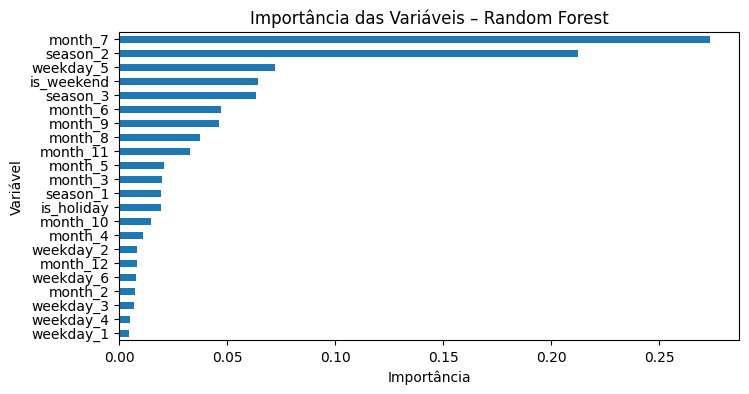

In [170]:
# Para One-Hot Encoding
ohe_features = preprocessor.named_transformers_['cat'].get_feature_names_out(['month','weekday','season'])
num_features = ['is_weekend','is_holiday']
all_features = list(ohe_features) + num_features

# Agora criar Series
importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=True)

# Plot
plt.figure(figsize=(8,4))
importances.plot(kind='barh')
plt.title("Importância das Variáveis – Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()




*   **Matriz de Confusão**



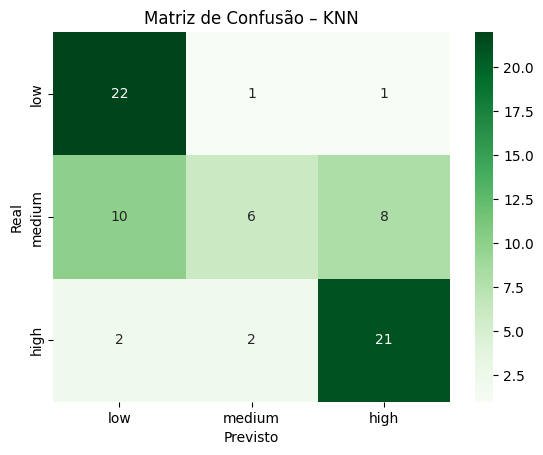

In [171]:
labels = ['low','medium','high']
cm = confusion_matrix(yc_test, yc_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de Confusão – KNN")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()


#**Insights**

In [172]:
print("1️⃣ Padrões Gerais:")
print("- Visitantes seguem padrões sazonais: mês e estação são os fatores mais importantes.")
print("- Finais de semana e feriados aumentam o fluxo, mas têm impacto menor.")
print("- Dias médios de visitação são mais difíceis de prever.\n")

print("2️⃣ Desempenho dos Modelos:")
print(f"- Random Forest (Regressão): R² = {r2_score(y_test, y_pred_rf):.3f}, MAE = {mean_absolute_error(y_test, y_pred_rf):.2f}")
print("- Captura bem picos e baixos, mas dias médios ainda têm erro.\n")

print("- KNN (Classificação): Accuracy ≈ 0.67")
print("- Classe 'high' e 'low' são previsíveis, classe 'medium' tem recall baixo.\n")

print("3️⃣ Recomendações:")
print("- Planejar recursos e estoque de acordo com mês/estação.")
print("- Usar promoções para aumentar visitas em dias médios.")
print("- Coletar dados extras (clima, eventos, marketing) para melhorar previsões.")


1️⃣ Padrões Gerais:
- Visitantes seguem padrões sazonais: mês e estação são os fatores mais importantes.
- Finais de semana e feriados aumentam o fluxo, mas têm impacto menor.
- Dias médios de visitação são mais difíceis de prever.

2️⃣ Desempenho dos Modelos:
- Random Forest (Regressão): R² = 0.612, MAE = 592.91
- Captura bem picos e baixos, mas dias médios ainda têm erro.

- KNN (Classificação): Accuracy ≈ 0.67
- Classe 'high' e 'low' são previsíveis, classe 'medium' tem recall baixo.

3️⃣ Recomendações:
- Planejar recursos e estoque de acordo com mês/estação.
- Usar promoções para aumentar visitas em dias médios.
- Coletar dados extras (clima, eventos, marketing) para melhorar previsões.
